# Deeper Playground | Redes neuronales sobre formas geometricas

Una red por cada forma del set, siguiendo CRISP-DM. Al final graficamos la superficie de decision de cada red.

## 1. Comprension del negocio

Queremos ver cuanta red hace falta para separar cada forma: las casi rectas con una red chica, las enroscadas con mas profundidad.

In [1]:
import os
import warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

## 2. Comprension de los datos

Diez hojas, una por forma, todas con X1, X2, la etiqueta -1/+1 y el color. Las cargamos todas para explorarlas.

In [2]:
RUTA = "data/Set_de_datos_inspirados_en_tensorflow.xlsx"
xls = pd.ExcelFile(RUTA, engine="openpyxl")

def cargar_forma(hoja):
    df = pd.read_excel(xls, hoja).dropna().reset_index(drop=True)
    df.columns = [str(c).strip() for c in df.columns]
    df = df.rename(columns={"f(X1, X2)": "label_raw"})
    df["y"] = (df["label_raw"] == 1).astype(int)
    df["clase"] = df["Type"].astype(str).str.strip()
    return df[["X1", "X2", "label_raw", "y", "clase"]]

formas = {h.strip(): cargar_forma(h) for h in xls.sheet_names}
list(formas.keys())

['1. Media Luna abstracta',
 '2. Infinito A',
 '3. Circulo doble abstracto',
 '4. Cuadrantes',
 '5. Blobls',
 '6. Espiral detallada',
 '7. Media luna clara',
 '8. Corazon dividido',
 '9. Flor detallada',
 '10. Infinito B']

In [3]:
resumen = pd.DataFrame([
    {"forma": nombre,
     "n": len(df),
     "azul": int((df["y"] == 1).sum()),
     "naranja": int((df["y"] == 0).sum()),
     "balance": round((df["y"] == 1).mean(), 2),
     "X1_min": round(df["X1"].min(), 1), "X1_max": round(df["X1"].max(), 1),
     "X2_min": round(df["X2"].min(), 1), "X2_max": round(df["X2"].max(), 1)}
    for nombre, df in formas.items()
])
resumen

,forma,n,azul,naranja,balance,X1_min,X1_max,X2_min,X2_max
0,1. Media Luna abstracta,200,100,100,0.50,-1.2,2.2,-0.7,1.2
1,2. Infinito A,200,100,100,0.50,-10.4,10.3,-5.4,5.3
2,3. Circulo doble abstracto,200,100,100,0.50,-3.2,3.6,-2.8,3.1
3,4. Cuadrantes,200,93,107,0.46,-5.0,5.0,-5.0,4.8
4,5. Blobls,200,100,100,0.50,-3.6,4.3,-3.9,3.9
5,6. Espiral detallada,200,100,100,0.50,-12.5,12.5,-11.0,11.0
6,7. Media luna clara,200,100,100,0.50,-3.1,6.1,-1.7,3.2
7,8. Corazon dividido,200,100,100,0.50,-5.1,5.1,-5.2,4.0
8,9. Flor detallada,200,100,100,0.50,-4.2,4.2,-4.1,4.8
9,10. Infinito B,200,100,100,0.50,-5.4,5.2,-2.9,2.8


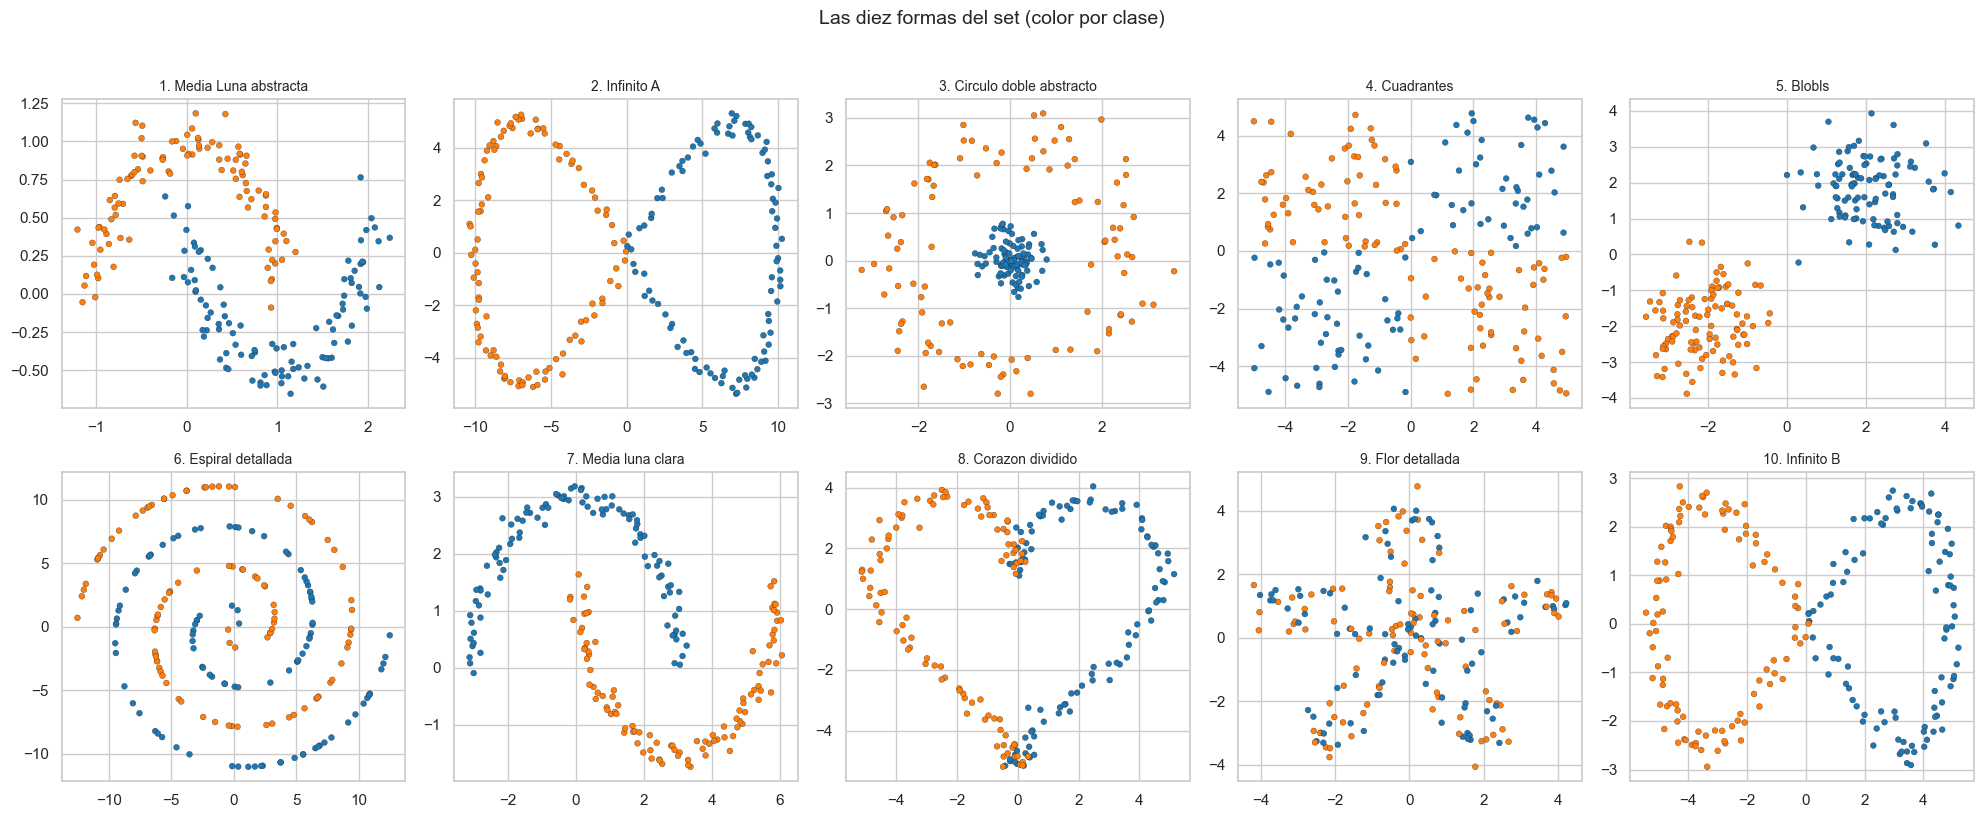

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, (nombre, df) in zip(axes.ravel(), formas.items()):
    sns.scatterplot(data=df, x="X1", y="X2", hue="clase",
                    palette={"AZUL": "#1f77b4", "NARANJA": "#ff7f0e"},
                    s=18, edgecolor="k", linewidth=0.2, ax=ax, legend=False)
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("Las diez formas del set (color por clase)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Para poner numero a la dificultad medimos cuanto separa una recta sola: si rinde como el azar, la forma es bien no lineal.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

sep = []
for nombre, df in formas.items():
    X = df[["X1", "X2"]].values
    y = df["y"].values
    acc_lin = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5).mean()
    sep.append({"forma": nombre, "acc_lineal_cv": round(acc_lin, 3)})
sep = pd.DataFrame(sep).sort_values("acc_lineal_cv", ascending=False).reset_index(drop=True)
sep

,forma,acc_lineal_cv
0,2. Infinito A,0.995
1,5. Blobls,0.995
2,10. Infinito B,0.980
3,7. Media luna clara,0.885
4,1. Media Luna abstracta,0.870
5,8. Corazon dividido,0.630
6,3. Circulo doble abstracto,0.580
7,6. Espiral detallada,0.580
8,4. Cuadrantes,0.560
9,9. Flor detallada,0.495


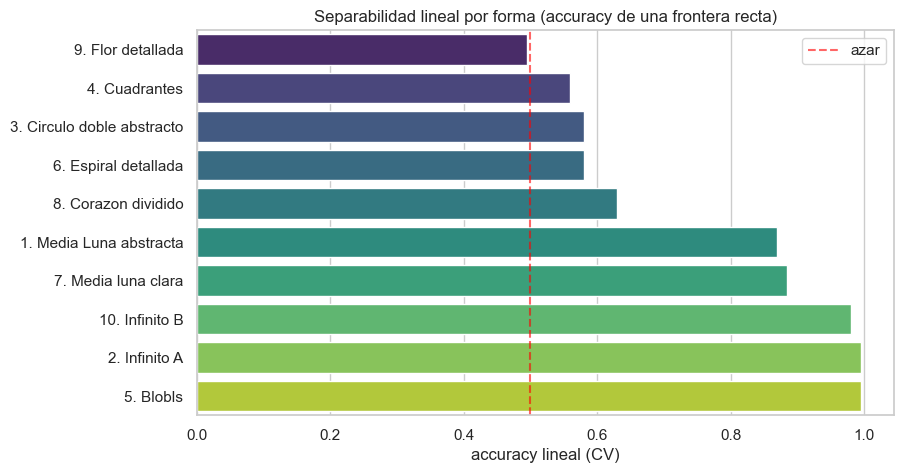

In [6]:
plt.figure(figsize=(9, 5))
orden = sep.sort_values("acc_lineal_cv")
sns.barplot(data=orden, y="forma", x="acc_lineal_cv", palette="viridis")
plt.axvline(0.5, color="red", ls="--", alpha=0.6, label="azar")
plt.title("Separabilidad lineal por forma (accuracy de una frontera recta)")
plt.xlabel("accuracy lineal (CV)"); plt.ylabel("")
plt.legend()
plt.show()

In [7]:
df_esp = formas["6. Espiral detallada"].copy()
fig = px.scatter(df_esp, x="X1", y="X2", color="clase",
                 color_discrete_map={"AZUL": "#1f77b4", "NARANJA": "#ff7f0e"},
                 title="Espiral detallada: la forma mas dificil del set (interactivo)")
fig.update_traces(marker=dict(size=8, line=dict(width=0.5, color="black")))
fig

## 3. Preparacion de los datos

Elegimos cinco formas que cubren todo el rango: Blobs, Media luna clara, Circulo doble, Corazon dividido y Espiral. Para cada una, split 75/25 estratificado y `StandardScaler` ajustado solo en train.

In [8]:
FORMAS_TP = [
    "5. Blobls",
    "7. Media luna clara",
    "3. Circulo doble abstracto",
    "8. Corazon dividido",
    "6. Espiral detallada",
]
NOMBRE_LINDO = {
    "5. Blobls": "Blobs",
    "7. Media luna clara": "Media luna clara",
    "3. Circulo doble abstracto": "Circulo doble",
    "8. Corazon dividido": "Corazon dividido",
    "6. Espiral detallada": "Espiral detallada",
}

def preparar(nombre):
    df = formas[nombre]
    X = df[["X1", "X2"]].values
    y = df["y"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_SEED)
    scaler = StandardScaler().fit(X_train)
    return {
        "nombre": NOMBRE_LINDO[nombre],
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "X_train_s": scaler.transform(X_train),
        "X_test_s": scaler.transform(X_test),
        "scaler": scaler,
    }

datos = {nombre: preparar(nombre) for nombre in FORMAS_TP}
pd.DataFrame([
    {"forma": d["nombre"], "train": len(d["X_train"]), "test": len(d["X_test"]),
     "balance_train": round(d["y_train"].mean(), 2)}
    for d in datos.values()
])

,forma,train,test,balance_train
0,Blobs,150,50,0.5
1,Media luna clara,150,50,0.5
2,Circulo doble,150,50,0.5
3,Corazon dividido,150,50,0.5
4,Espiral detallada,150,50,0.5


## 4. Modelado

Una red por forma: arrancamos chico y agrandamos segun la dificultad.

| Forma | Capas ocultas |
|---|---|
| Blobs | `[4]` |
| Media luna clara | `[8, 8]` |
| Circulo doble | `[16, 8]` |
| Corazon dividido | `[32, 16]` |
| Espiral detallada | `[64, 64, 32]` |

Todas con salida `Dense(1, sigmoid)`, `binary_crossentropy`, ReLU y Adam (lr=0.01).

In [9]:
def construir_red(arquitectura, learning_rate=0.01):
    modelo = keras.Sequential([layers.Input(shape=(2,))])
    for unidades in arquitectura:
        modelo.add(layers.Dense(unidades, activation="relu"))
    modelo.add(layers.Dense(1, activation="sigmoid"))
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate),
                   loss="binary_crossentropy", metrics=["accuracy"])
    return modelo

def entrenar_red(d, arquitectura, epochs, batch_size=16, learning_rate=0.01):
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    modelo = construir_red(arquitectura, learning_rate)
    history = modelo.fit(d["X_train_s"], d["y_train"],
                         validation_split=0.2, epochs=epochs,
                         batch_size=batch_size, verbose=0)
    return modelo, history

In [10]:
CONFIG = {
    "Blobs":            {"arquitectura": [4],          "epochs": 100},
    "Media luna clara": {"arquitectura": [8, 8],       "epochs": 200},
    "Circulo doble":    {"arquitectura": [16, 8],      "epochs": 200},
    "Corazon dividido": {"arquitectura": [32, 16],     "epochs": 250},
    "Espiral detallada":{"arquitectura": [64, 64, 32], "epochs": 300},
}

modelos = {}
historias = {}
for nombre_hoja, d in datos.items():
    nombre = d["nombre"]
    cfg = CONFIG[nombre]
    modelo, history = entrenar_red(d, cfg["arquitectura"], cfg["epochs"])
    modelos[nombre] = modelo
    historias[nombre] = history
    print(f"{nombre:18s} arquitectura={cfg['arquitectura']!s:16s} parametros={modelo.count_params():4d} epochs={cfg['epochs']}")

Blobs              arquitectura=[4]              parametros=  17 epochs=100


Media luna clara   arquitectura=[8, 8]           parametros= 105 epochs=200


Circulo doble      arquitectura=[16, 8]          parametros= 193 epochs=200


Corazon dividido   arquitectura=[32, 16]         parametros= 641 epochs=250


Espiral detallada  arquitectura=[64, 64, 32]     parametros=6465 epochs=300


In [11]:
modelos["Espiral detallada"].summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,397 (75.77 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,932 (50.52 KB)

## 5. Evaluacion

Por forma: accuracy, precision, recall y F1 en test, matriz de confusion, curvas por epoca y superficie de decision (meshgrid escalado, `contourf` y puntos de test encima).

In [12]:
def evaluar(d, modelo):
    y_test = d["y_test"]
    proba = modelo.predict(d["X_test_s"], verbose=0).ravel()
    pred = (proba > 0.5).astype(int)
    return {
        "forma": d["nombre"],
        "accuracy": round(accuracy_score(y_test, pred), 3),
        "precision": round(precision_score(y_test, pred, zero_division=0), 3),
        "recall": round(recall_score(y_test, pred, zero_division=0), 3),
        "f1": round(f1_score(y_test, pred, zero_division=0), 3),
        "pred": pred, "proba": proba,
    }

evaluaciones = {d["nombre"]: evaluar(d, modelos[d["nombre"]]) for d in datos.values()}
tabla_metricas = pd.DataFrame([
    {k: v for k, v in e.items() if k in ("forma", "accuracy", "precision", "recall", "f1")}
    for e in evaluaciones.values()
])
tabla_metricas

,forma,accuracy,precision,recall,f1
0,Blobs,1.00,1.00,1.00,1.00
1,Media luna clara,1.00,1.00,1.00,1.00
2,Circulo doble,1.00,1.00,1.00,1.00
3,Corazon dividido,0.92,0.92,0.92,0.92
4,Espiral detallada,0.98,1.00,0.96,0.98


In [13]:
print("Reporte de clasificacion por forma (test)")
for d in datos.values():
    nombre = d["nombre"]
    ev = evaluaciones[nombre]
    print("=" * 60)
    print(nombre)
    print(classification_report(d["y_test"], ev["pred"],
                                target_names=["NARANJA", "AZUL"], zero_division=0))

Reporte de clasificacion por forma (test)
Blobs
              precision    recall  f1-score   support

     NARANJA       1.00      1.00      1.00        25
        AZUL       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Media luna clara
              precision    recall  f1-score   support

     NARANJA       1.00      1.00      1.00        25
        AZUL       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Circulo doble
              precision    recall  f1-score   support

     NARANJA       1.00      1.00      1.00        25
        AZUL       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00      

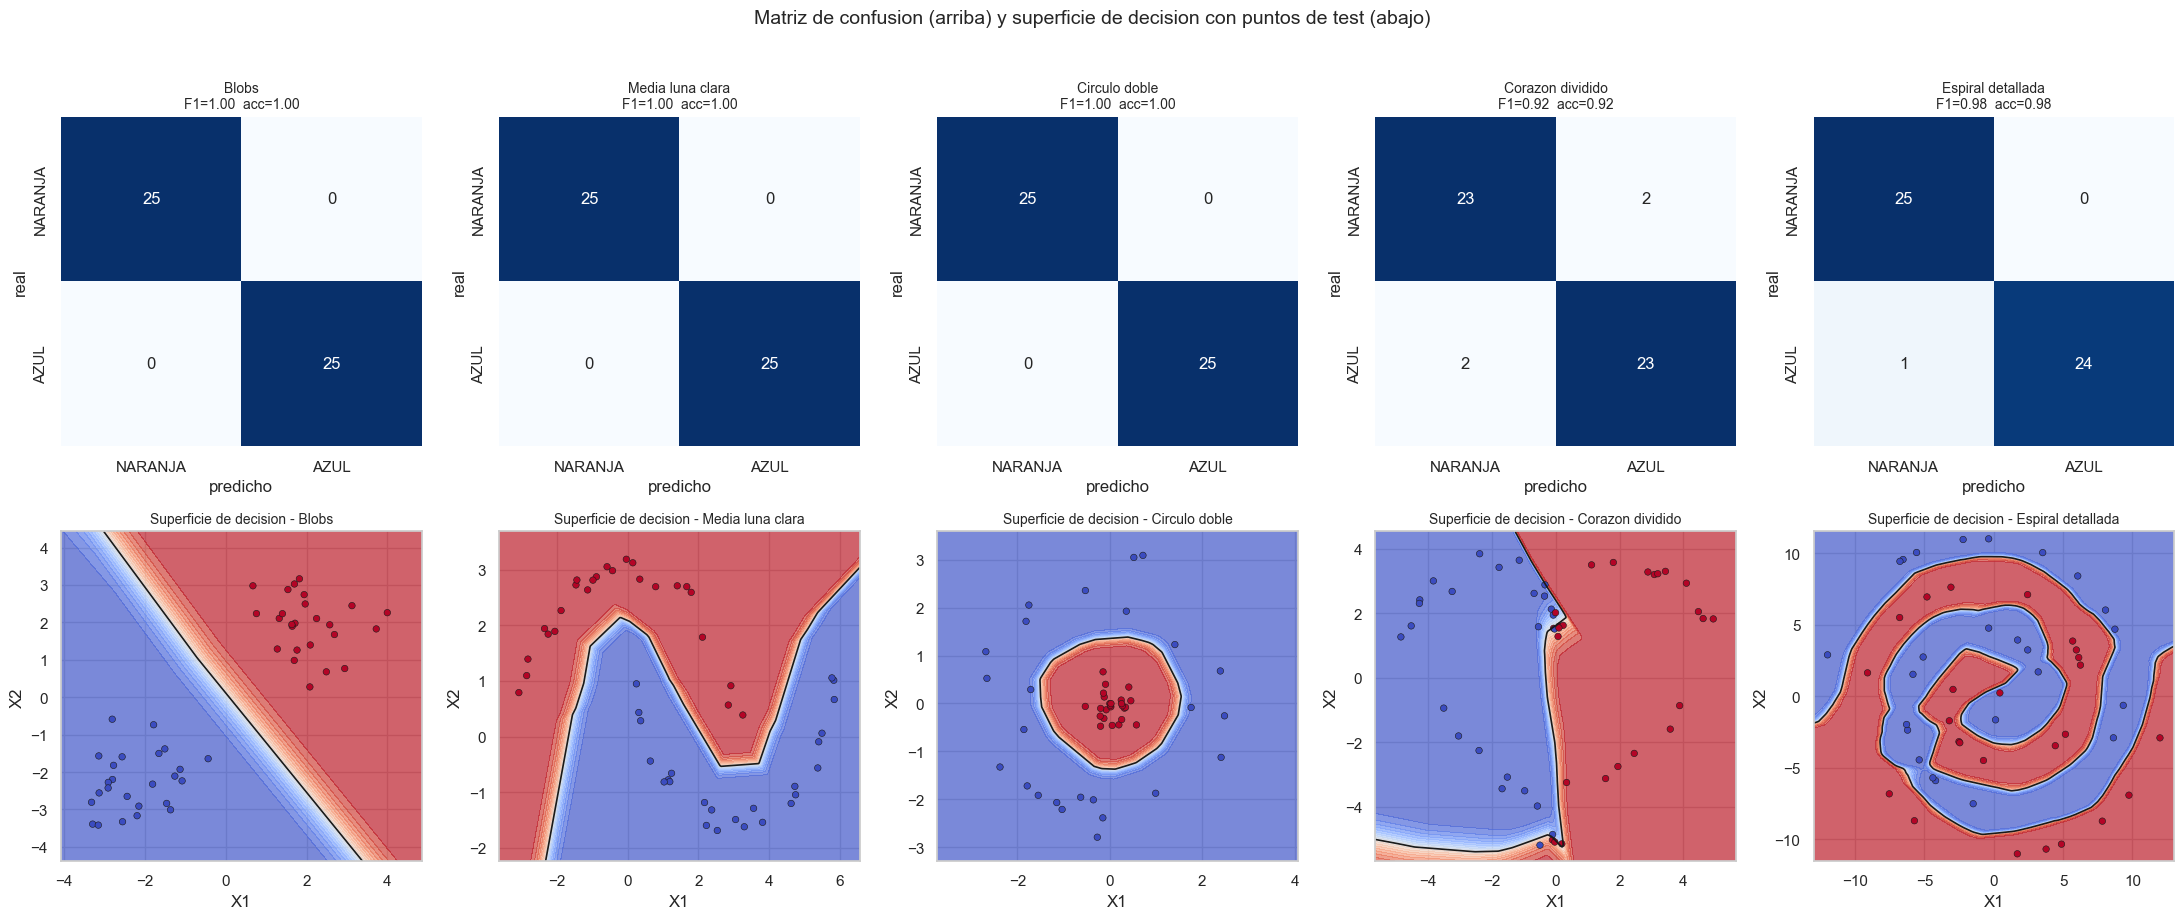

In [14]:
def superficie_grilla(d, modelo, paso=300):
    X = np.vstack([d["X_train"], d["X_test"]])
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, paso),
                         np.linspace(y_min, y_max, paso))
    grilla = np.c_[xx.ravel(), yy.ravel()]
    grilla_s = d["scaler"].transform(grilla)
    zz = modelo.predict(grilla_s, verbose=0).reshape(xx.shape)
    return xx, yy, zz

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for col, d in enumerate(datos.values()):
    nombre = d["nombre"]
    modelo = modelos[nombre]
    ev = evaluaciones[nombre]

    ax = axes[0, col]
    cm = confusion_matrix(d["y_test"], ev["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["NARANJA", "AZUL"], yticklabels=["NARANJA", "AZUL"], ax=ax)
    ax.set_title(f"{nombre}\nF1={ev['f1']:.2f}  acc={ev['accuracy']:.2f}", fontsize=10)
    ax.set_ylabel("real"); ax.set_xlabel("predicho")

    ax = axes[1, col]
    xx, yy, zz = superficie_grilla(d, modelo)
    ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 21), cmap="coolwarm", alpha=0.7)
    ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=1.2)
    ax.scatter(d["X_test"][:, 0], d["X_test"][:, 1], c=d["y_test"],
               cmap="coolwarm", s=22, edgecolor="k", linewidth=0.4)
    ax.set_title(f"Superficie de decision - {nombre}", fontsize=10)
    ax.set_xlabel("X1"); ax.set_ylabel("X2")
plt.suptitle("Matriz de confusion (arriba) y superficie de decision con puntos de test (abajo)",
             y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

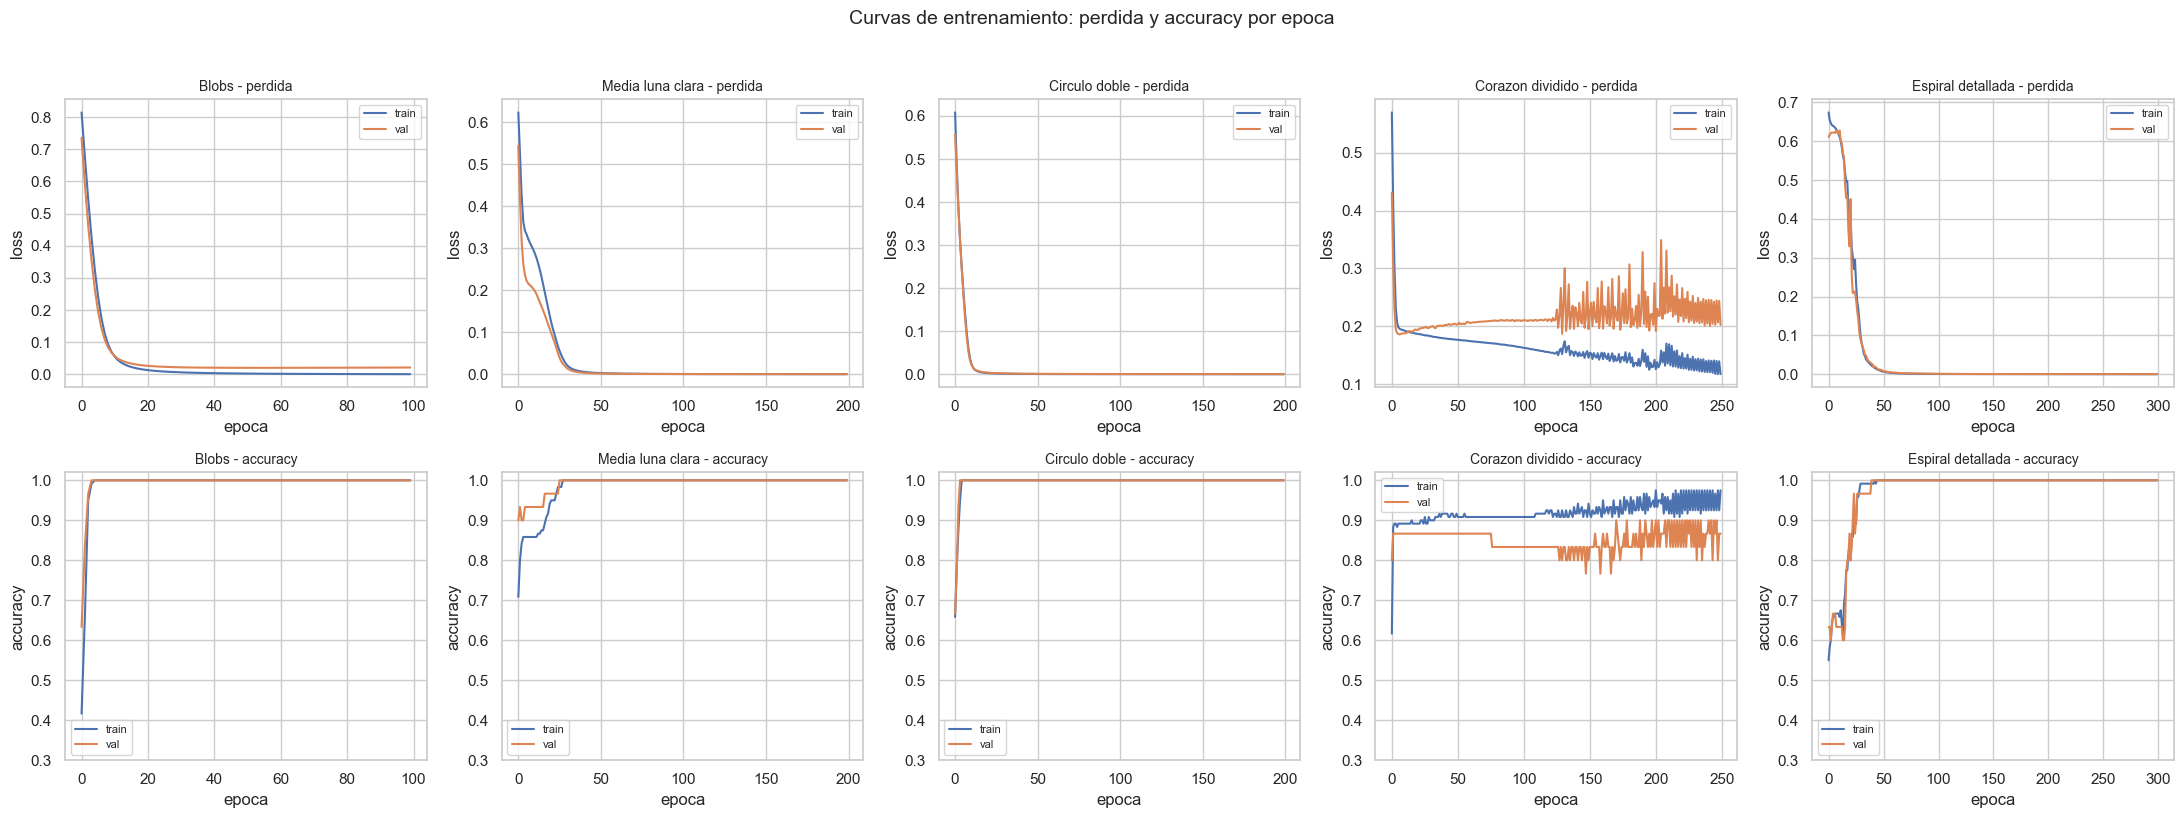

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for col, d in enumerate(datos.values()):
    nombre = d["nombre"]
    h = historias[nombre].history

    ax = axes[0, col]
    ax.plot(h["loss"], label="train")
    ax.plot(h["val_loss"], label="val")
    ax.set_title(f"{nombre} - perdida", fontsize=10)
    ax.set_xlabel("epoca"); ax.set_ylabel("loss")
    ax.legend(fontsize=8)

    ax = axes[1, col]
    ax.plot(h["accuracy"], label="train")
    ax.plot(h["val_accuracy"], label="val")
    ax.set_title(f"{nombre} - accuracy", fontsize=10)
    ax.set_xlabel("epoca"); ax.set_ylabel("accuracy")
    ax.set_ylim(0.3, 1.02)
    ax.legend(fontsize=8)
plt.suptitle("Curvas de entrenamiento: perdida y accuracy por epoca", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

La espiral es donde mas se ve la frontera enroscada, asi que la graficamos aparte con Plotly mostrando la probabilidad continua sobre el plano.

In [16]:
d = datos["6. Espiral detallada"]
modelo = modelos["Espiral detallada"]
xx, yy, zz = superficie_grilla(d, modelo, paso=200)
df_pts = pd.DataFrame({
    "X1": np.concatenate([d["X_train"][:, 0], d["X_test"][:, 0]]),
    "X2": np.concatenate([d["X_train"][:, 1], d["X_test"][:, 1]]),
    "clase": np.where(np.concatenate([d["y_train"], d["y_test"]]) == 1, "AZUL", "NARANJA"),
})
fig = go.Figure()
fig.add_trace(go.Contour(x=xx[0], y=yy[:, 0], z=zz,
                         colorscale="RdBu", reversescale=True, opacity=0.75,
                         contours=dict(showlines=False), colorbar=dict(title="P(AZUL)")))
for clase, color in [("NARANJA", "#ff7f0e"), ("AZUL", "#1f77b4")]:
    sub = df_pts[df_pts["clase"] == clase]
    fig.add_trace(go.Scatter(x=sub["X1"], y=sub["X2"], mode="markers", name=clase,
                             marker=dict(size=7, color=color,
                                         line=dict(width=0.5, color="black"))))
fig.update_layout(title="Superficie de decision de la espiral (probabilidad continua, interactivo)",
                  xaxis_title="X1", yaxis_title="X2", width=820, height=680)
fig

In [17]:
fig = px.bar(tabla_metricas.melt(id_vars="forma", var_name="metrica", value_name="valor"),
             x="forma", y="valor", color="metrica", barmode="group",
             title="Metricas de test por forma (interactivo)",
             category_orders={"forma": [d["nombre"] for d in datos.values()]})
fig.update_layout(yaxis_range=[0, 1.05], width=900, height=520)
fig

## 6. Arquitectura del modelo en Excel

Llevamos a Excel el forward pass de la red de Blobs (`[4]`), con los pesos y bias reales: una hoja con un ejemplo y otra con las matrices.

In [18]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

modelo_xls = modelos["Blobs"]
d_xls = datos["5. Blobls"]
weights = modelo_xls.get_weights()
W1, b1 = weights[0], weights[1]
W2, b2 = weights[2], weights[3]
n_oculta = W1.shape[1]

ejemplo_raw = d_xls["X_test"][0]
ejemplo = d_xls["X_test_s"][0]
print("Ejemplo (X1, X2) crudo:", np.round(ejemplo_raw, 4), "-> escalado:", np.round(ejemplo, 4))
print("Capa oculta: W1", W1.shape, "b1", b1.shape, "| Salida: W2", W2.shape, "b2", b2.shape)

Ejemplo (X1, X2) crudo: [1.8233 3.1643] -> escalado: [0.8247 1.5885]
Capa oculta: W1 (2, 4) b1 (4,) | Salida: W2 (4, 1) b2 (1,)


In [19]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z1 = ejemplo @ W1 + b1
a1 = relu(z1)
z2 = a1 @ W2.ravel() + b2[0]
a2 = sigmoid(z2)
print("Activaciones ocultas (ReLU):", np.round(a1, 4))
print("Salida (sigmoide):", round(float(a2), 4), "-> clase:", "AZUL" if a2 > 0.5 else "NARANJA")

Activaciones ocultas (ReLU): [0.0485 0.     3.9076 2.9043]
Salida (sigmoide): 1.0 -> clase: AZUL


In [20]:
wb = openpyxl.Workbook()
hdr_fill = PatternFill("solid", fgColor="305496")
hdr_font = Font(bold=True, color="FFFFFF")
sub_fill = PatternFill("solid", fgColor="D9E1F2")
bold = Font(bold=True)
thin = Border(*[Side(style="thin", color="B0B0B0")] * 4)
center = Alignment(horizontal="center")

ws = wb.active
ws.title = "Forward pass"
ws["A1"] = "Arquitectura: red Blobs  [Input(2) -> Dense(4, relu) -> Dense(1, sigmoide)]"
ws["A1"].font = Font(bold=True, size=12)
ws["A2"] = "Forward pass de un ejemplo del test, con los pesos y bias reales aprendidos por la red."

ws["A4"] = "Entrada (features escaladas con StandardScaler ajustado en train)"
ws["A4"].font = bold
ws["A5"], ws["B5"], ws["C5"] = "BIAS", "X1", "X2"
ws["A6"], ws["B6"], ws["C6"] = 1.0, round(float(ejemplo[0]), 6), round(float(ejemplo[1]), 6)
for c in ("A5", "B5", "C5"):
    ws[c].fill = sub_fill; ws[c].font = bold; ws[c].alignment = center

ws["A8"] = "Capa oculta: z = X1*w1 + X2*w2 + BIAS*b ;  a = ReLU(z)"
ws["A8"].font = bold
encab = ["Neurona", "w(X1)", "w(X2)", "bias", "z = suma ponderada", "a = ReLU(z)"]
for j, t in enumerate(encab):
    c = ws.cell(row=9, column=1 + j, value=t)
    c.fill = hdr_fill; c.font = hdr_font; c.alignment = center; c.border = thin
for i in range(n_oculta):
    zi = float(ejemplo @ W1[:, i] + b1[i])
    ai = max(0.0, zi)
    fila = [f"H{i+1}", round(float(W1[0, i]), 6), round(float(W1[1, i]), 6),
            round(float(b1[i]), 6), round(zi, 6), round(ai, 6)]
    for j, v in enumerate(fila):
        c = ws.cell(row=10 + i, column=1 + j, value=v); c.border = thin
        if j == 0:
            c.font = bold

fila_out = 10 + n_oculta + 1
ws.cell(row=fila_out, column=1, value="Capa de salida: z = sum(a_i * w_i) + bias ;  y = sigmoide(z)").font = bold
encab2 = ["Entrada"] + [f"a(H{i+1})" for i in range(n_oculta)] + ["bias", "z salida", "y = sigmoide(z)", "clase"]
for j, t in enumerate(encab2):
    c = ws.cell(row=fila_out + 1, column=1 + j, value=t)
    c.fill = hdr_fill; c.font = hdr_font; c.alignment = center; c.border = thin
fila_vals = ["pesos -> "] + [round(float(W2[i, 0]), 6) for i in range(n_oculta)] + [round(float(b2[0]), 6), "", "", ""]
for j, v in enumerate(fila_vals):
    c = ws.cell(row=fila_out + 2, column=1 + j, value=v); c.border = thin
a1_vec = relu(ejemplo @ W1 + b1)
z2v = float(a1_vec @ W2.ravel() + b2[0])
y2v = float(sigmoid(z2v))
fila_vals2 = ["activacion -> "] + [round(float(a1_vec[i]), 6) for i in range(n_oculta)] + ["", round(z2v, 6), round(y2v, 6), "AZUL" if y2v > 0.5 else "NARANJA"]
for j, v in enumerate(fila_vals2):
    c = ws.cell(row=fila_out + 3, column=1 + j, value=v); c.border = thin
    if j == 0:
        c.font = bold

for col, w in zip("ABCDEFG", [12, 12, 12, 12, 20, 16, 12]):
    ws.column_dimensions[col].width = w

ws2 = wb.create_sheet("Pesos y bias")
ws2["A1"] = "Matrices de pesos y bias reales (model.get_weights())"
ws2["A1"].font = Font(bold=True, size=12)

ws2["A3"] = "W1  (capa oculta, forma 2 x 4): filas = entradas X1, X2 ; columnas = neuronas H1..H4"
ws2["A3"].font = bold
ws2["A4"] = ""
for j in range(n_oculta):
    c = ws2.cell(row=4, column=2 + j, value=f"H{j+1}"); c.fill = hdr_fill; c.font = hdr_font; c.alignment = center
for i, nm in enumerate(["X1", "X2"]):
    ws2.cell(row=5 + i, column=1, value=nm).font = bold
    for j in range(n_oculta):
        ws2.cell(row=5 + i, column=2 + j, value=round(float(W1[i, j]), 6)).border = thin

ws2["A8"] = "b1  (bias capa oculta, 4 valores)"
ws2["A8"].font = bold
for j in range(n_oculta):
    ws2.cell(row=9, column=1 + j, value=f"H{j+1}").fill = sub_fill
    ws2.cell(row=10, column=1 + j, value=round(float(b1[j]), 6)).border = thin

ws2["A12"] = "W2  (capa de salida, forma 4 x 1): filas = neuronas H1..H4 ; columna = salida"
ws2["A12"].font = bold
for i in range(n_oculta):
    ws2.cell(row=13 + i, column=1, value=f"H{i+1}").font = bold
    ws2.cell(row=13 + i, column=2, value=round(float(W2[i, 0]), 6)).border = thin

ws2["A18"] = "b2  (bias capa de salida)"
ws2["A18"].font = bold
ws2.cell(row=19, column=1, value=round(float(b2[0]), 6)).border = thin

for col, w in zip("ABCDE", [16, 12, 12, 12, 12]):
    ws2.column_dimensions[col].width = w

xlsx_path = "arquitectura_deeper-playground.xlsx"
wb.save(xlsx_path)
print("Excel de arquitectura generado:", xlsx_path)

Excel de arquitectura generado: arquitectura_deeper-playground.xlsx


## 7. Comparacion y reflexion

Los resultados acompañan la dificultad: Blobs, Media luna y Circulo doble llegan a F1 casi perfecto, la Espiral queda muy alta con la red profunda y el Corazon es el unico que no cierra del todo.

Lo unico que movimos fue la capacidad (`[4]` hasta `[64,64,32]`). Como mejoras: features polares en las formas radiales, early stopping o dropout donde hay brecha train/val, y mas puntos cerca del borde.